# Pitch Usage Experiments

Three non-traditional visualizations to replace the standard horizontal bar chart: **Treemap**, **Radial Gauge**, and **Sequencing Barcode**.

## Step 1: Setup and Data Loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import squarify
from pathlib import Path

# Mallitalytics brand palette (from pitcher_card_gemini.py)
PALETTE = {
    "card_bg":       "#131B23", 
    "header_bg":     "#1C2836",
    "panel_bg":      "#1A2430",
    "table_bg":      "#16202A",
    "table_alt":     "#1C2836",
    "text_primary":  "#F5F2ED",
    "text_secondary":"#A8BDD0",
    "text_lo":       "#5D7A93",
    "accent_orange": "#E8712B",
    "accent_green":  "#66BB6A",
    "accent_red":    "#E74C3C",
    "grid":          "#2C3E50",
    "border":        "#2E4A62",
    "zone_edge":     "#8FA3B8",
}

PITCH_COLOURS = {
    'FF': {'colour': '#FF007D', 'name': '4-Seam'},
    'SI': {'colour': '#98165D', 'name': 'Sinker'},
    'FC': {'colour': '#BE5FA0', 'name': 'Cutter'},
    'CH': {'colour': '#F79E70', 'name': 'Changeup'},
    'FS': {'colour': '#FE6100', 'name': 'Splitter'},
    'SL': {'colour': '#67E18D', 'name': 'Slider'},
    'ST': {'colour': '#1BB999', 'name': 'Sweeper'},
    'CU': {'colour': '#3025CE', 'name': 'Curveball'},
    'KC': {'colour': '#311D8B', 'name': 'Knuck. Curve'},
    'UN': {'colour': '#9C8975', 'name': 'Unknown'},
}
DICT_COLOUR = {k: v['colour'] for k, v in PITCH_COLOURS.items()}
DICT_PITCH  = {k: v['name']   for k, v in PITCH_COLOURS.items()}

def load_game(parquet_path, pitcher_id):
    df = pd.read_parquet(parquet_path)
    col = "pitcher" if "pitcher" in df.columns else "pitcher_id"
    df = df[df[col] == pitcher_id].copy()
    if df.empty:
        raise ValueError(f"Pitcher {pitcher_id} not found.")
    return df

def process_pitches(df):
    swing_codes = ['foul_bunt','foul','hit_into_play','swinging_strike','foul_tip','swinging_strike_blocked','missed_bunt','bunt_foul_tip']
    whiff_codes = ['swinging_strike','foul_tip','swinging_strike_blocked']
    df = df.copy()
    df['swing']     = df['description'].isin(swing_codes)
    df['whiff']     = df['description'].isin(whiff_codes)
    df['in_zone']   = df['zone'] < 10
    df['out_zone']  = df['zone'] > 10
    df['chase']     = (~df['in_zone']) & df['swing']
    df['is_strike'] = df['type'] == 'S'
    df['pfx_z_in']  = df['pfx_z'] * 12
    df['pfx_x_in']  = df['pfx_x'] * 12
    if 'launch_speed' in df.columns:
        df['hard_hit'] = df['launch_speed'] >= 95.0
    else:
        df['hard_hit'] = False
    if 'estimated_woba_using_speedangle' in df.columns:
        df['is_damage'] = (df['hard_hit']) | (df['estimated_woba_using_speedangle'] >= 0.350)
    else:
        df['is_damage'] = df['hard_hit']
    return df

In [5]:
PARQUET_PATH = Path("/Users/gilrojasb/Desktop/Mallitalytics_VS/MLB/data/warehouse/mlb/2025/regular_season/pitches_enriched/game_776136_20250928_pitches_enriched.parquet")
PITCHER_ID = 676664

df_raw = load_game(str(PARQUET_PATH), PITCHER_ID)
df = process_pitches(df_raw)

# Ensure we have pitch_type and stand (batter stance)
assert 'pitch_type' in df.columns and 'stand' in df.columns, "Need pitch_type and stand"
df['pitch_type'] = df['pitch_type'].fillna('UN').astype(str)
df['stand'] = df['stand'].fillna('R').astype(str)

print(f"Loaded {len(df)} pitches. Pitch types: {df['pitch_type'].unique().tolist()}")
print(f"vs LHB: {(df['stand']=='L').sum()}, vs RHB: {(df['stand']=='R').sum()}")

Loaded 113 pitches. Pitch types: ['CH', 'SI', 'FF', 'ST', 'FC', 'SL']
vs LHB: 20, vs RHB: 93


## Step 2: Option 1 — The Arsenal Treemap

Side-by-side treemap: **left = vs LHB**, **right = vs RHB**. Rectangle size = pitch frequency; colors from `DICT_COLOUR`.

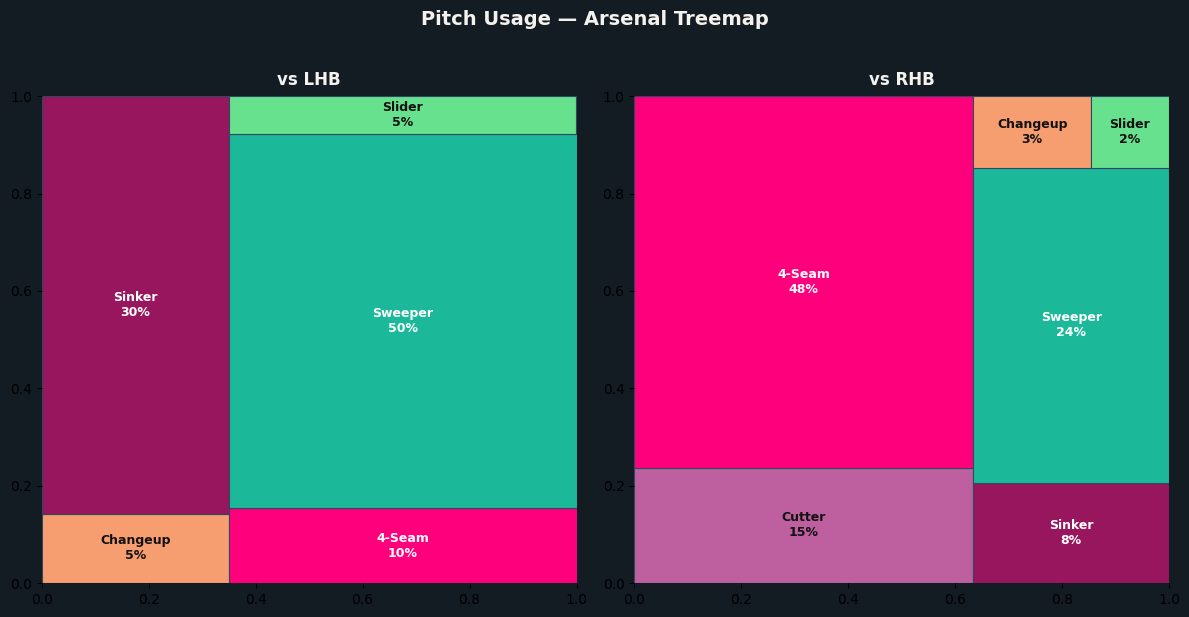

In [6]:
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 6))
fig.patch.set_facecolor(PALETTE["card_bg"])

def plot_treemap_side(ax, sub_df, title):
    ax.set_facecolor(PALETTE["panel_bg"])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    for spine in ax.spines.values():
        spine.set_visible(False)
    if sub_df.empty:
        ax.text(0.5, 0.5, "No pitches", color=PALETTE["text_secondary"], ha='center', va='center', transform=ax.transAxes)
        return
    counts = sub_df.groupby('pitch_type').size().reindex(sub_df['pitch_type'].unique()).fillna(0).astype(int)
    counts = counts[counts > 0]
    if counts.empty:
        return
    labels = [DICT_PITCH.get(pt, pt) for pt in counts.index]
    colors = [DICT_COLOUR.get(pt, '#9C8975') for pt in counts.index]
    sizes = counts.values
    norm = squarify.normalize_sizes(sizes, 1, 1)
    rects = squarify.squarify(norm, 0, 0, 1, 1)
    for r, pt, color in zip(rects, counts.index, colors):
        rect = mpatches.Rectangle((r['x'], r['y']), r['dx'], r['dy'], facecolor=color, edgecolor=PALETTE['border'], linewidth=0.8)
        ax.add_patch(rect)
        pct = counts[pt] / counts.sum() * 100
        ax.text(r['x'] + r['dx']/2, r['y'] + r['dy']/2, f"{DICT_PITCH.get(pt, pt)}\n{pct:.0f}%",
                color='#111111' if (sum(mpl.colors.to_rgb(color)) / 3) > 0.5 else '#FFFFFF',
                ha='center', va='center', fontsize=9, fontweight='bold')
    ax.set_title(title, color=PALETTE["text_primary"], fontsize=12, fontweight='bold', pad=8)

df_l = df[df['stand'] == 'L']
df_r = df[df['stand'] == 'R']
plot_treemap_side(ax_l, df_l, "vs LHB")
plot_treemap_side(ax_r, df_r, "vs RHB")
plt.suptitle("Pitch Usage — Arsenal Treemap", color=PALETTE["text_primary"], fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 3: Option 2 — The Radial Usage Gauge

Semi-circle (180°) polar plot: **inner ring = vs LHB**, **outer ring = vs RHB**. Radial bar length = usage %. High-tech dashboard style.

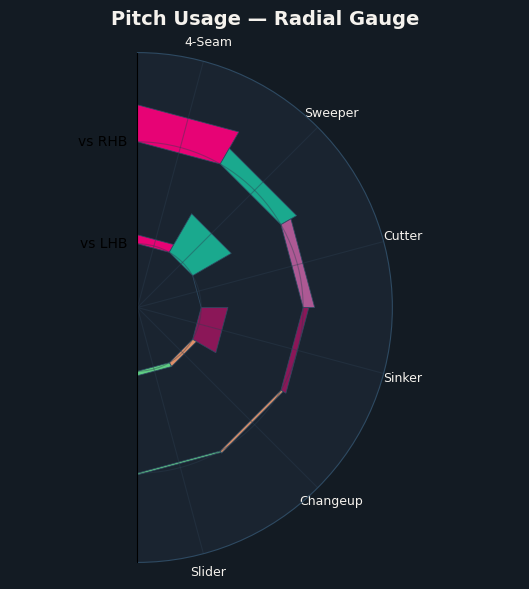

In [22]:
from math import pi

pitch_types = df['pitch_type'].value_counts().index.tolist()
n = len(pitch_types)
if n == 0:
    n = 1
    pitch_types = ['UN']

df_l = df[df['stand'] == 'L']
df_r = df[df['stand'] == 'R']
total_l = len(df_l) or 1
total_r = len(df_r) or 1
pct_l = [len(df_l[df_l['pitch_type'] == pt]) / total_l for pt in pitch_types]
pct_r = [len(df_r[df_r['pitch_type'] == pt]) / total_r for pt in pitch_types]

fig = plt.figure(figsize=(10, 6))
fig.patch.set_facecolor(PALETTE["card_bg"])
ax = fig.add_subplot(111, projection='polar')
ax.set_facecolor(PALETTE["panel_bg"])

# Semi-circle: use only 0 to pi (180°)
theta = np.linspace(0, np.pi, n + 1)
width = (np.pi / n) * 0.85

# Inner ring (LHB) — radius 0.25 to 0.25 + pct
for i, pt in enumerate(pitch_types):
    r_inner, r_outer = 0.25, 0.25 + 0.35 * pct_l[i]
    t = [theta[i], theta[i], theta[i+1], theta[i+1]]
    r = [r_inner, r_outer, r_outer, r_inner]
    ax.fill(t, r, facecolor=DICT_COLOUR.get(pt, '#9C8975'), edgecolor=PALETTE['border'], linewidth=0.6, alpha=0.9)

# Outer ring (RHB) — radius 0.65 to 0.65 + pct
for i, pt in enumerate(pitch_types):
    r_inner, r_outer = 0.65, 0.65 + 0.30 * pct_r[i]
    t = [theta[i], theta[i], theta[i+1], theta[i+1]]
    r = [r_inner, r_outer, r_outer, r_inner]
    ax.fill(t, r, facecolor=DICT_COLOUR.get(pt, '#9C8975'), edgecolor=PALETTE['border'], linewidth=0.6, alpha=0.9)

ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
ax.set_thetamin(0)
ax.set_thetamax(180)
ax.set_ylim(0, 1.0)
ax.set_yticks([0.25, 0.65])
ax.set_yticklabels(['vs LHB', 'vs RHB'], color=PALETTE['text_secondary'], fontsize=9)
ax.set_xticks(theta[:-1] + (theta[1] - theta[0]) / 2)
ax.set_xticklabels([DICT_PITCH.get(pt, pt) for pt in pitch_types], color=PALETTE['text_primary'], fontsize=9)
ax.spines['polar'].set_color(PALETTE['border'])
ax.grid(True, color=PALETTE['grid'], alpha=0.4, linestyle='-')
ax.set_title("Pitch Usage — Radial Gauge", color=PALETTE["text_primary"], fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## Step 4: Option 3 — The Sequencing Barcode

**X** = pitch number (chronological). **Y** = two tracks: **top = vs LHB**, **bottom = vs RHB**. Each vertical line = one pitch, colored by `pitch_type`. DNA-barcode style, minimalist axes.

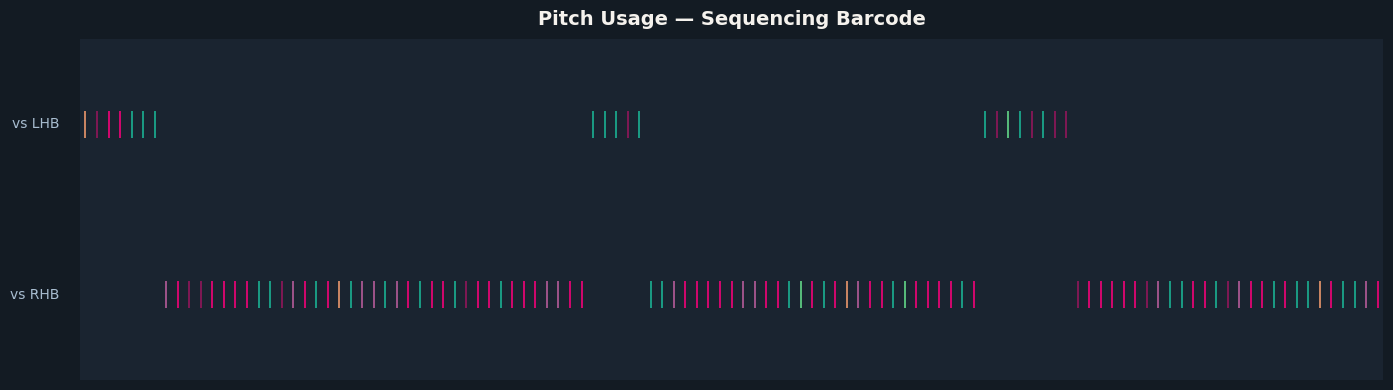

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor(PALETTE["card_bg"])
ax.set_facecolor(PALETTE["panel_bg"])

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

# Two tracks: 1 = vs LHB (top), 0 = vs RHB (bottom)
df = df.reset_index(drop=True)
df['pitch_num'] = np.arange(len(df))
df['track'] = (df['stand'] == 'L').astype(int)

y_center = {0: 0.25, 1: 0.75}
line_h = 0.08

for _, row in df.iterrows():
    x = row['pitch_num']
    y = y_center[row['track']]
    color = DICT_COLOUR.get(row['pitch_type'], '#9C8975')
    ax.vlines(x, y - line_h/2, y + line_h/2, colors=color, linewidth=1.2, alpha=0.95)

ax.set_xlim(-0.5, len(df) - 0.5)
ax.set_ylim(0, 1)
ax.text(-0.02 * len(df), 0.75, "vs LHB", color=PALETTE['text_secondary'], fontsize=10, ha='right', va='center')
ax.text(-0.02 * len(df), 0.25, "vs RHB", color=PALETTE['text_secondary'], fontsize=10, ha='right', va='center')
ax.set_title("Pitch Usage — Sequencing Barcode", color=PALETTE["text_primary"], fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

## Option 4 — The Heartbeat (Velo-Sequencing)

**X** = pitch number (chronological). **Y** = pitch velocity (mph). Large colored dots show the sequence; the line traces up and down by how hard each pitch was thrown. Reveals sequence mix and whether the pitcher was tiring late.

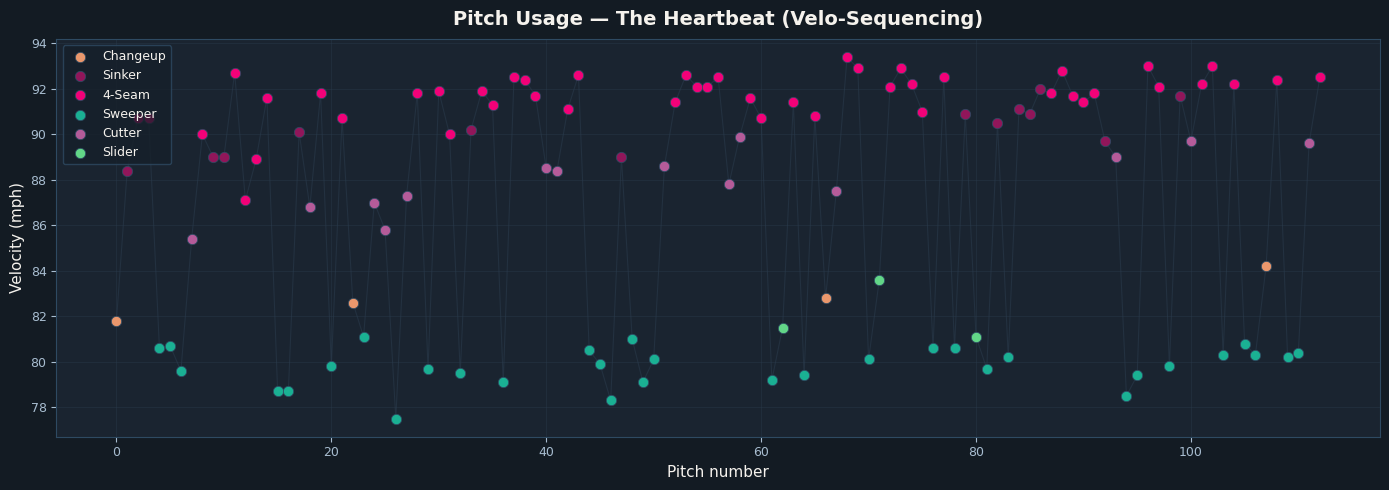

In [11]:
# Use release_speed (velocity in mph); ensure we have pitch number
if 'pitch_num' not in df.columns:
    df = df.reset_index(drop=True)
    df['pitch_num'] = np.arange(len(df))

velo = df['release_speed'].values
pitch_num = df['pitch_num'].values
pitch_types_seq = df['pitch_type'].values

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(PALETTE["card_bg"])
ax.set_facecolor(PALETTE["panel_bg"])

# Thin connecting line (heartbeat trace) in a neutral color
ax.plot(pitch_num, velo, color=PALETTE["grid"], linewidth=0.8, alpha=0.5, zorder=1)

# Large colored dots by pitch type
for pt in df['pitch_type'].unique():
    mask = pitch_types_seq == pt
    ax.scatter(pitch_num[mask], velo[mask], c=DICT_COLOUR.get(pt, '#9C8975'), s=55, alpha=0.95,
               edgecolors=PALETTE['border'], linewidths=0.6, zorder=2, label=DICT_PITCH.get(pt, pt))

ax.set_xlabel("Pitch number", color=PALETTE["text_primary"], fontsize=11)
ax.set_ylabel("Velocity (mph)", color=PALETTE["text_primary"], fontsize=11)
ax.tick_params(colors=PALETTE["text_secondary"], labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor(PALETTE["border"])
ax.grid(True, color=PALETTE["grid"], alpha=0.35, linestyle='-')
ax.legend(loc='upper left', frameon=True, facecolor=PALETTE["table_bg"], edgecolor=PALETTE["border"],
          labelcolor=PALETTE["text_primary"], fontsize=9)
ax.set_title("Pitch Usage — The Heartbeat (Velo-Sequencing)", color=PALETTE["text_primary"], fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

## Option 5 — The "Pitch Ribbon" (Continuous Blocks)

Two horizontal ribbons: **Top = vs LHB**, **Bottom = vs RHB**. Each pitch is a wide, solid block of color using `ax.barh` (or Rectangles). Blocks touch to form a continuous ribbon; ribbon height is substantial so colors pop.

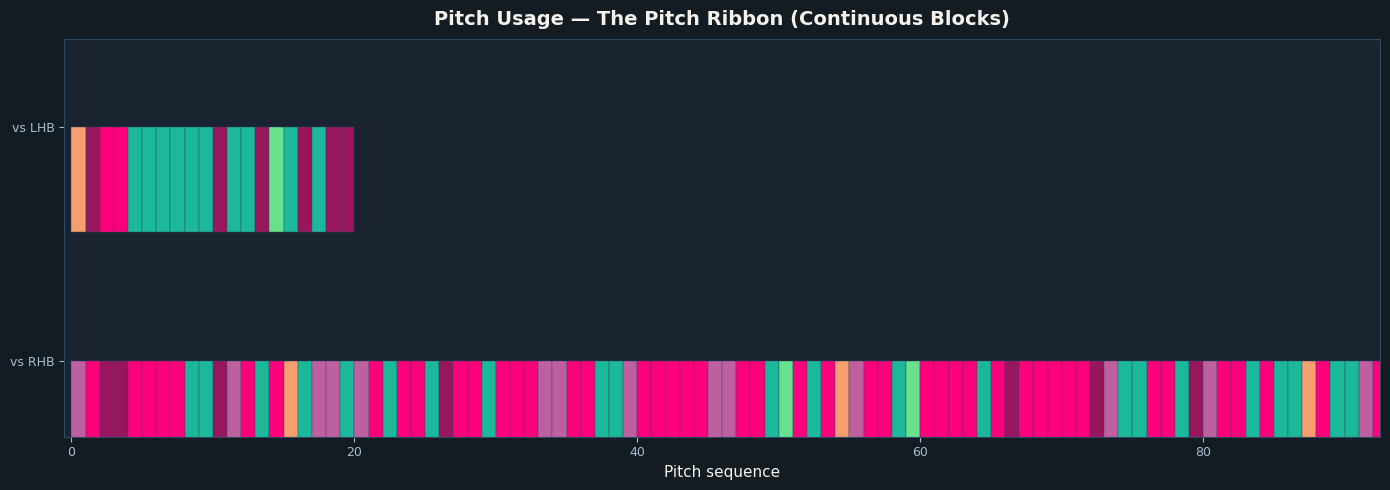

In [12]:
# Pitch Ribbon: two horizontal ribbons (LHB top, RHB bottom), thick contiguous blocks
if 'pitch_num' not in df.columns:
    df = df.reset_index(drop=True)
    df['pitch_num'] = np.arange(len(df))

df_l = df[df['stand'] == 'L'].reset_index(drop=True)
df_r = df[df['stand'] == 'R'].reset_index(drop=True)
n_l, n_r = len(df_l), len(df_r)
ribbon_height = 0.45
y_top_bottom = 1.0   # y of bottom edge of top ribbon (barh uses y = bottom of bar)
y_bot_bottom = 0.0   # y of bottom edge of bottom ribbon

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(PALETTE["card_bg"])
ax.set_facecolor(PALETTE["panel_bg"])

# Top ribbon — vs LHB (bars from y=1.0 to 1.45)
for i in range(n_l):
    pt = df_l.iloc[i]['pitch_type']
    ax.barh(y_top_bottom, 1.0, left=i, height=ribbon_height,
            color=DICT_COLOUR.get(pt, '#9C8975'), edgecolor=PALETTE['border'], linewidth=0.3)
# Bottom ribbon — vs RHB (bars from y=0 to 0.45)
for i in range(n_r):
    pt = df_r.iloc[i]['pitch_type']
    ax.barh(y_bot_bottom, 1.0, left=i, height=ribbon_height,
            color=DICT_COLOUR.get(pt, '#9C8975'), edgecolor=PALETTE['border'], linewidth=0.3)

ax.set_xlim(-0.5, max(n_l, n_r) - 0.5)
ax.set_ylim(-0.1, 1.6)
ax.set_yticks([y_bot_bottom + ribbon_height / 2, y_top_bottom + ribbon_height / 2])
ax.set_yticklabels(['vs RHB', 'vs LHB'], color=PALETTE["text_primary"], fontsize=10)
ax.set_xlabel("Pitch sequence", color=PALETTE["text_primary"], fontsize=11)
ax.tick_params(colors=PALETTE["text_secondary"], labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor(PALETTE["border"])
ax.set_title("Pitch Usage — The Pitch Ribbon (Continuous Blocks)", color=PALETTE["text_primary"], fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

## Option 6 — The "Sheet Music" (Categorical Scatter)

- **X-axis** = `pitch_number` (chronological).
- **Y-axis** = `pitch_name` (categorical: 4-Seam, Slider, etc.).
- Large solid scatter points (`s=150`) colored by pitch type (`DICT_COLOUR`).
- Faint horizontal grid line for each pitch type to guide the eye — like notes on sheet music.

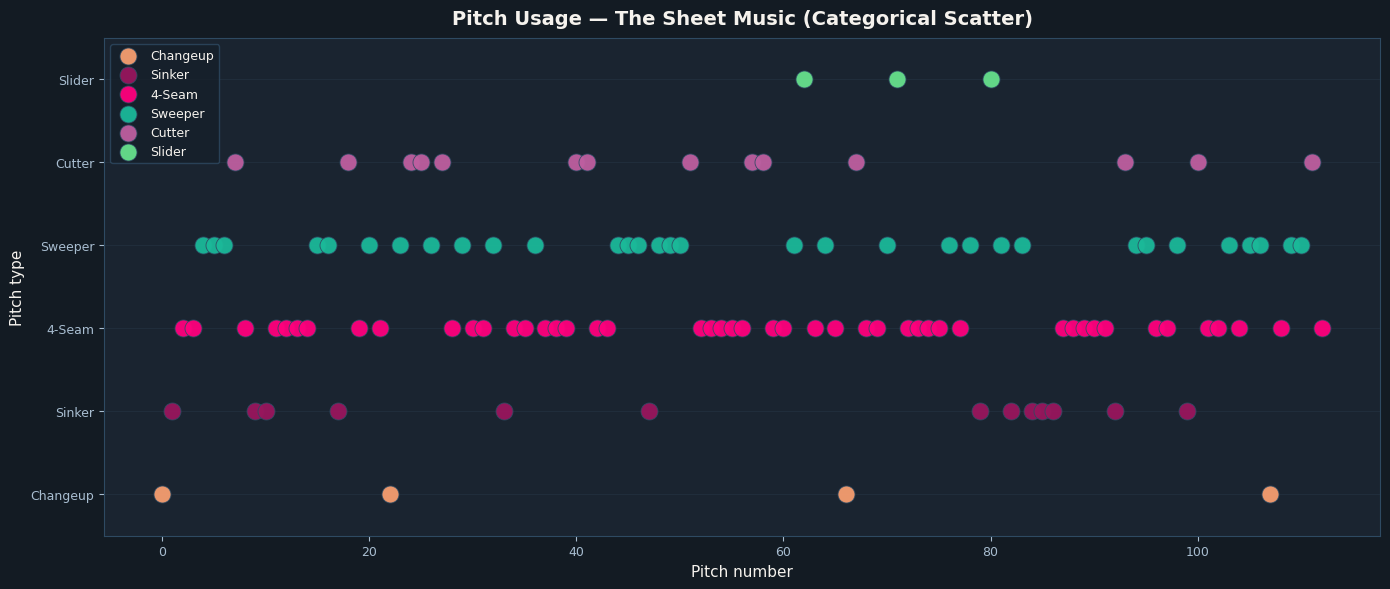

In [13]:
# Sheet Music: X = pitch_number, Y = pitch_name (categorical), large colored points + faint grid
if 'pitch_num' not in df.columns:
    df = df.reset_index(drop=True)
    df['pitch_num'] = np.arange(len(df))

# Ordered list of pitch types (by first appearance or sorted) for stable y-axis
pitch_order = df['pitch_type'].unique().tolist()
pitch_to_y = {pt: i for i, pt in enumerate(pitch_order)}
df_plot = df.copy()
df_plot['y_cat'] = df_plot['pitch_type'].map(pitch_to_y)
df_plot['pitch_name'] = df_plot['pitch_type'].map(lambda x: DICT_PITCH.get(x, x))

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(PALETTE["card_bg"])
ax.set_facecolor(PALETTE["panel_bg"])

# Faint horizontal grid at each pitch type
for yi in range(len(pitch_order)):
    ax.axhline(y=yi, color=PALETTE["grid"], alpha=0.35, linewidth=0.8, zorder=0)

# Scatter: large solid points colored by pitch type
for pt in pitch_order:
    mask = df_plot['pitch_type'] == pt
    ax.scatter(df_plot.loc[mask, 'pitch_num'], df_plot.loc[mask, 'y_cat'],
               c=DICT_COLOUR.get(pt, '#9C8975'), s=150, alpha=0.95, edgecolors=PALETTE['border'],
               linewidths=0.6, zorder=2, label=DICT_PITCH.get(pt, pt))

ax.set_xlabel("Pitch number", color=PALETTE["text_primary"], fontsize=11)
ax.set_ylabel("Pitch type", color=PALETTE["text_primary"], fontsize=11)
ax.set_yticks(range(len(pitch_order)))
ax.set_yticklabels([DICT_PITCH.get(pt, pt) for pt in pitch_order], color=PALETTE["text_primary"], fontsize=10)
ax.tick_params(colors=PALETTE["text_secondary"], labelsize=9)
ax.set_ylim(-0.5, len(pitch_order) - 0.5)
for spine in ax.spines.values():
    spine.set_edgecolor(PALETTE["border"])
ax.legend(loc='upper left', frameon=True, facecolor=PALETTE["table_bg"], edgecolor=PALETTE["border"],
          labelcolor=PALETTE["text_primary"], fontsize=9)
ax.set_title("Pitch Usage — The Sheet Music (Categorical Scatter)", color=PALETTE["text_primary"], fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

## Option 7 — Arsenal Table with Embedded Velo Sparklines

Custom Matplotlib table with **FancyBboxPatch** row styling. Columns: **Pitch**, **%**, **Velo**, **Trend**, **iVB**, **HB**, **Whiff%**, **xwOBA**. The **Trend** column embeds a mini chronological line chart of `release_speed` (velocity stamina) per pitch type, with a white dot on the final point. Dark mode aesthetic with color-coded Whiff% and xwOBA badges.

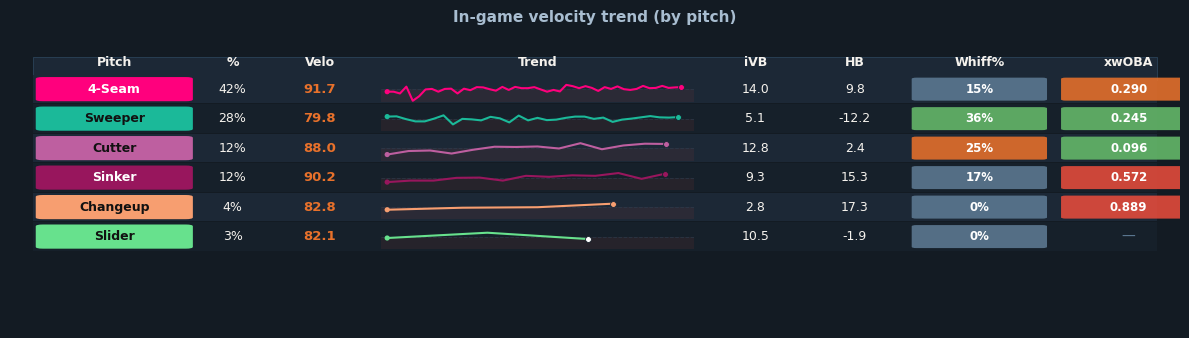

In [30]:
from matplotlib.patches import FancyBboxPatch

# Use same df as Step 1 (pitcher's game data: load_game + process_pitches)
if 'estimated_woba_using_speedangle' not in df.columns:
    df = df.assign(estimated_woba_using_speedangle=np.nan)
arsenal = df.groupby('pitch_type').agg(
    count=('pitch_type', 'count'), velo=('release_speed', 'mean'), max_velo=('release_speed', 'max'),
    pfx_z=('pfx_z_in', 'mean'), pfx_x=('pfx_x_in', 'mean'),
    swing=('swing', 'sum'), whiff=('whiff', 'sum'), in_zone=('in_zone', 'sum'),
    xwoba=('estimated_woba_using_speedangle', 'mean'),
).reset_index()
total = len(df)
arsenal['usage_pct'] = arsenal['count'] / total
arsenal['whiff_pct'] = arsenal['whiff'] / arsenal['swing'].replace(0, np.nan)
arsenal['name'] = arsenal['pitch_type'].map(DICT_PITCH).fillna(arsenal['pitch_type'])
arsenal['colour'] = arsenal['pitch_type'].map(DICT_COLOUR).fillna('#9C8975')
arsenal = arsenal.sort_values('count', ascending=False).reset_index(drop=True)

COLS = ["Pitch", "%", "Velo", "Trend", "iVB", "HB", "Whiff%", "xwOBA"]
WIDTHS = [0.13, 0.06, 0.08, 0.27, 0.08, 0.08, 0.12, 0.12]  # Trend = sparkline
tw = sum(WIDTHS)
WIDTHS = [w / tw for w in WIDTHS]
# Shared y-axis for velocity vs in-game mean (0 = average; above/below = harder/softer)
all_deltas = []
for pt in df['pitch_type'].unique():
    v = df.loc[df['pitch_type'] == pt, 'release_speed'].dropna().values
    if len(v) > 0:
        all_deltas.extend((v - v.mean()).tolist())
if all_deltas:
    d_abs = max(2.0, np.abs(all_deltas).max() + 0.3)
    d_lo, d_hi = -d_abs, d_abs
else:
    d_lo, d_hi = -2, 2
HDR_Y, ROW_H, SEP_Y = 0.92, 0.10, 0.88

fig, ax = plt.subplots(figsize=(12, 1.2 + len(arsenal) * 0.38))
fig.patch.set_facecolor(PALETTE["card_bg"])
ax.set_facecolor(PALETTE["panel_bg"])
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_axis_off()

# Header
ax.add_patch(FancyBboxPatch((0.02, SEP_Y - 0.04), 0.96, 0.08, boxstyle="square,pad=0",
                            facecolor=PALETTE["header_bg"], edgecolor=PALETTE["border"], linewidth=0.5,
                            transform=ax.transAxes, zorder=0))
x = 0.02
for col, w in zip(COLS, WIDTHS):
    ax.text(x + w / 2, HDR_Y - 0.02, col, ha='center', va='center', transform=ax.transAxes,
            color=PALETTE["text_primary"], fontsize=9, fontweight='bold')
    x += w

def _lum(hex_c):
    r, g, b = mpl.colors.to_rgb(hex_c)
    return 0.299 * r + 0.587 * g + 0.114 * b

y_top = SEP_Y - ROW_H * 0.7
for ri, r in arsenal.iterrows():
    yc = y_top - ri * ROW_H
    bg = PALETTE["table_alt"] if ri % 2 == 0 else PALETTE["table_bg"]
    ax.add_patch(FancyBboxPatch((0.02, yc - ROW_H * 0.48), 0.96, ROW_H * 0.96,
                                boxstyle="square,pad=0", lw=0, facecolor=bg,
                                transform=ax.transAxes, zorder=0))
    x = 0.02
    for ci, (col, w) in enumerate(zip(COLS, WIDTHS)):
        xc = x + w / 2
        if ci == 0:
            ax.add_patch(FancyBboxPatch((x + 0.008, yc - ROW_H * 0.35), w - 0.016, ROW_H * 0.70,
                                        boxstyle="round,pad=0.006", lw=0, facecolor=r['colour'],
                                        transform=ax.transAxes, zorder=1))
            tc = '#111111' if _lum(r['colour']) > 0.50 else '#FFFFFF'
            ax.text(xc, yc, r['name'], ha='center', va='center', fontsize=9, fontweight='bold',
                    color=tc, transform=ax.transAxes, zorder=2)
        elif ci == 1:
            ax.text(xc, yc, f"{r['usage_pct']:.0%}", ha='center', va='center', fontsize=9,
                    color=PALETTE["text_primary"], transform=ax.transAxes)
        elif ci == 2:
            ax.text(xc, yc, f"{r['velo']:.1f}", ha='center', va='center', fontsize=9.5, fontweight='bold',
                    color=PALETTE["accent_orange"], transform=ax.transAxes)
        elif ci == 3:
            # Trend: velocity vs in-game mean for this pitch (sparkline)
            df_pt = df[df['pitch_type'] == r['pitch_type']].copy()
            df_pt = df_pt.dropna(subset=['release_speed']).sort_index()
            if len(df_pt) > 0:
                ia = ax.inset_axes([x + 0.01, yc - ROW_H * 0.42, w - 0.02, ROW_H * 0.84])
                ia.set_facecolor(bg)
                velo = df_pt['release_speed'].values
                n = len(velo)
                delta = velo - velo.mean()
                # Faint fatigue zone below average; dashed zero line
                ia.axhspan(ymin=d_lo, ymax=0, facecolor=PALETTE["accent_red"], alpha=0.08, zorder=0)
                ia.axhline(0, color=PALETTE["grid"], alpha=0.6, linewidth=0.7, linestyle='--', zorder=1)
                # Solid trend line
                ia.plot(np.arange(n), delta, color=r['colour'], linewidth=1.5, zorder=2)
                # Above-average dots: subsample to ~12 so we keep the "harder than avg" texture without clutter
                above_avg = np.where(delta > 0)[0]
                max_dots = 12
                if len(above_avg) > max_dots:
                    idx = np.linspace(0, len(above_avg) - 1, max_dots, dtype=int)
                    above_avg = above_avg[idx]
                if len(above_avg) > 0:
                    ia.scatter(above_avg, delta[above_avg], color=r['colour'], s=10, alpha=0.85, zorder=3, edgecolors='none')
                # First and last markers
                ia.scatter([0], [delta[0]], c=r['colour'], s=14, zorder=4, edgecolors='none')
                final_color = '#FFFFFF' if delta[-1] <= 0 else r['colour']
                ia.scatter([n - 1], [delta[-1]], c=final_color, s=18, zorder=4, edgecolors=bg, linewidths=0.6)
                ia.set_axis_off()
                ia.set_xlim(-0.02 * n, n * 1.02 if n > 1 else 1)
                ia.set_ylim(d_lo, d_hi)
            else:
                ax.text(xc, yc, "—", ha='center', va='center', color=PALETTE["text_lo"], transform=ax.transAxes)
        elif ci == 4:
            ax.text(xc, yc, f"{r['pfx_z']:.1f}" if pd.notna(r['pfx_z']) else "—",
                    ha='center', va='center', fontsize=9, color=PALETTE["text_primary"], transform=ax.transAxes)
        elif ci == 5:
            ax.text(xc, yc, f"{r['pfx_x']:.1f}" if pd.notna(r['pfx_x']) else "—",
                    ha='center', va='center', fontsize=9, color=PALETTE["text_primary"], transform=ax.transAxes)
        elif ci == 6:
            wv = r['whiff_pct']
            if pd.notnull(wv):
                bc = PALETTE["accent_green"] if wv > 0.28 else PALETTE["accent_orange"] if wv > 0.18 else PALETTE["text_lo"]
                ax.add_patch(FancyBboxPatch((x + 0.01, yc - ROW_H * 0.35), w - 0.02, ROW_H * 0.70,
                                            boxstyle="round,pad=0.004", lw=0, facecolor=bc, alpha=0.88,
                                            transform=ax.transAxes, zorder=1))
                ax.text(xc, yc, f"{wv:.0%}", ha='center', va='center', fontsize=8.5, fontweight='bold',
                        color='#FFFFFF', transform=ax.transAxes, zorder=2)
            else:
                ax.text(xc, yc, "—", ha='center', va='center', color=PALETTE["text_lo"], transform=ax.transAxes)
        elif ci == 7:
            xv = r['xwoba']
            if pd.notnull(xv):
                bc = PALETTE["accent_green"] if xv < 0.280 else PALETTE["accent_orange"] if xv < 0.370 else PALETTE["accent_red"]
                ax.add_patch(FancyBboxPatch((x + 0.01, yc - ROW_H * 0.35), w - 0.02, ROW_H * 0.70,
                                            boxstyle="round,pad=0.004", lw=0, facecolor=bc, alpha=0.88,
                                            transform=ax.transAxes, zorder=1))
                ax.text(xc, yc, f"{xv:.3f}", ha='center', va='center', fontsize=8.5, fontweight='bold',
                        color='#FFFFFF', transform=ax.transAxes, zorder=2)
            else:
                ax.text(xc, yc, "—", ha='center', va='center', color=PALETTE["text_lo"], transform=ax.transAxes)
        x += w

ax.set_title("In-game velocity trend (by pitch)", color=PALETTE["text_secondary"], fontsize=11, fontweight='bold', pad=8)
plt.tight_layout()
plt.show()

## Stamina Delta (Δ Velo) — First half vs second half

Alternative 1: we calculate average velocity of the **first half** of the game vs the **second half** for each pitch type.  
**Visual:** A badge with **+0.8** (green) if he gained velocity in the 2nd half, or **-1.2** (red) if he lost velocity.  
Answers: *"Did he get tired?"* with a single number.

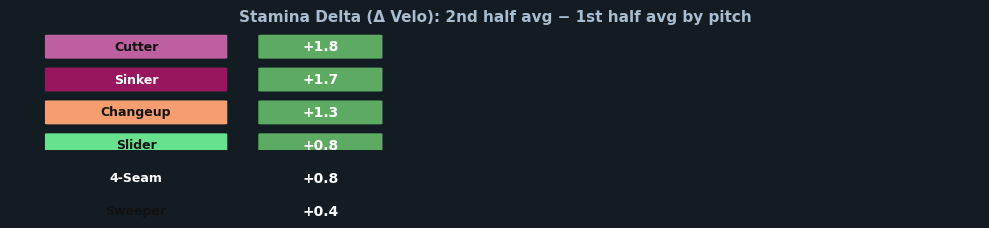

In [23]:
# Stamina Delta: first-half vs second-half avg velocity per pitch type (same game df)
from matplotlib.patches import FancyBboxPatch

def _lum(hex_c):
    r, g, b = mpl.colors.to_rgb(hex_c)
    return 0.299 * r + 0.587 * g + 0.114 * b

stamina_rows = []
for pt in df['pitch_type'].unique():
    sub = df[df['pitch_type'] == pt].dropna(subset=['release_speed'])
    if len(sub) < 2:
        continue
    n = len(sub)
    mid = n // 2
    first_half = sub['release_speed'].iloc[:mid].mean()
    second_half = sub['release_speed'].iloc[mid:].mean()
    delta = second_half - first_half  # positive = gained velo in 2nd half
    name = DICT_PITCH.get(pt, pt)
    colour = DICT_COLOUR.get(pt, '#9C8975')
    stamina_rows.append({'pitch_type': pt, 'name': name, 'colour': colour, 'delta': delta})

if not stamina_rows:
    print("Not enough pitch-level data for stamina delta.")
else:
    stamina = pd.DataFrame(stamina_rows).sort_values('delta', ascending=False)
    fig, ax = plt.subplots(figsize=(10, 0.8 + len(stamina) * 0.36))
    fig.patch.set_facecolor(PALETTE["card_bg"])
    ax.set_facecolor(PALETTE["panel_bg"])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_axis_off()
    ax.set_title("Stamina Delta (Δ Velo): 2nd half avg − 1st half avg by pitch", color=PALETTE["text_secondary"], fontsize=11, fontweight='bold', pad=8)

    row_h = 0.28
    y_top = 0.88
    for idx, (i, r) in enumerate(stamina.iterrows()):
        yc = y_top - idx * row_h
        # Pitch name pill
        ax.add_patch(FancyBboxPatch((0.04, yc - row_h * 0.35), 0.18, row_h * 0.7, boxstyle="round,pad=0.004", lw=0,
                                    facecolor=r['colour'], transform=ax.transAxes, zorder=1))
        tc = '#111111' if _lum(r['colour']) > 0.50 else '#FFFFFF'
        ax.text(0.13, yc, r['name'], ha='center', va='center', fontsize=9, fontweight='bold',
                color=tc, transform=ax.transAxes, zorder=2)
        # Delta badge: green if gained, red if lost
        d = r['delta']
        if abs(d) < 0.05:
            badge_color = PALETTE["text_lo"]
            txt = "0.0"
        else:
            badge_color = PALETTE["accent_green"] if d > 0 else PALETTE["accent_red"]
            txt = f"{d:+.1f}"
        ax.add_patch(FancyBboxPatch((0.26, yc - row_h * 0.35), 0.12, row_h * 0.7, boxstyle="round,pad=0.004", lw=0,
                                    facecolor=badge_color, alpha=0.9, transform=ax.transAxes, zorder=1))
        ax.text(0.32, yc, txt, ha='center', va='center', fontsize=10, fontweight='bold', color='#FFFFFF', transform=ax.transAxes, zorder=2)
    plt.tight_layout()
    plt.show()

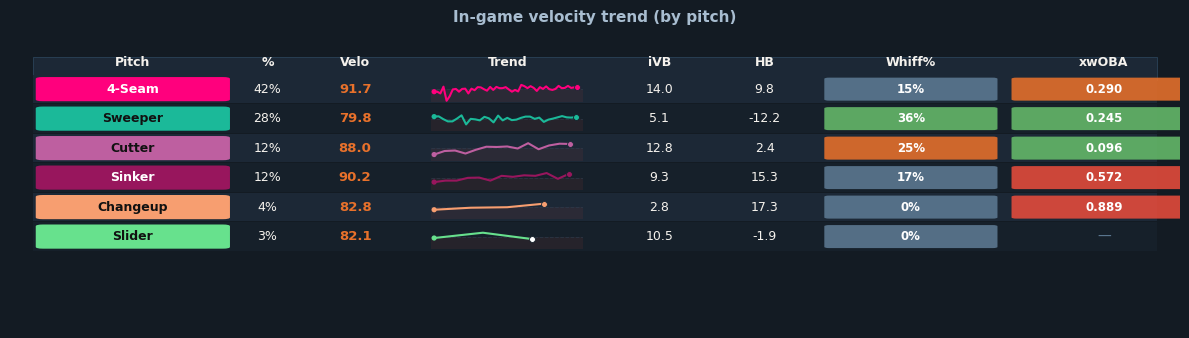

In [31]:
from matplotlib.patches import FancyBboxPatch

# Use same df as Step 1 (pitcher's game data: load_game + process_pitches)
if 'estimated_woba_using_speedangle' not in df.columns:
    df = df.assign(estimated_woba_using_speedangle=np.nan)
arsenal = df.groupby('pitch_type').agg(
    count=('pitch_type', 'count'), velo=('release_speed', 'mean'), max_velo=('release_speed', 'max'),
    pfx_z=('pfx_z_in', 'mean'), pfx_x=('pfx_x_in', 'mean'),
    swing=('swing', 'sum'), whiff=('whiff', 'sum'), in_zone=('in_zone', 'sum'),
    xwoba=('estimated_woba_using_speedangle', 'mean'),
).reset_index()
total = len(df)
arsenal['usage_pct'] = arsenal['count'] / total
arsenal['whiff_pct'] = arsenal['whiff'] / arsenal['swing'].replace(0, np.nan)
arsenal['name'] = arsenal['pitch_type'].map(DICT_PITCH).fillna(arsenal['pitch_type'])
arsenal['colour'] = arsenal['pitch_type'].map(DICT_COLOUR).fillna('#9C8975')
arsenal = arsenal.sort_values('count', ascending=False).reset_index(drop=True)

COLS = ["Pitch", "%", "Velo", "Trend", "iVB", "HB", "Whiff%", "xwOBA"]
WIDTHS = [0.17, 0.06, 0.09, 0.17, 0.09, 0.09, 0.16, 0.17]  
tw = sum(WIDTHS)
WIDTHS = [w / tw for w in WIDTHS]

# Shared y-axis for velocity vs in-game mean (0 = average; above/below = harder/softer)
all_deltas = []
for pt in df['pitch_type'].unique():
    v = df.loc[df['pitch_type'] == pt, 'release_speed'].dropna().values
    if len(v) > 0:
        all_deltas.extend((v - v.mean()).tolist())
if all_deltas:
    d_abs = max(2.0, np.abs(all_deltas).max() + 0.3)
    d_lo, d_hi = -d_abs, d_abs
else:
    d_lo, d_hi = -2, 2
HDR_Y, ROW_H, SEP_Y = 0.92, 0.10, 0.88

fig, ax = plt.subplots(figsize=(12, 1.2 + len(arsenal) * 0.38))
fig.patch.set_facecolor(PALETTE["card_bg"])
ax.set_facecolor(PALETTE["panel_bg"])
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_axis_off()

# Header
ax.add_patch(FancyBboxPatch((0.02, SEP_Y - 0.04), 0.96, 0.08, boxstyle="square,pad=0",
                            facecolor=PALETTE["header_bg"], edgecolor=PALETTE["border"], linewidth=0.5,
                            transform=ax.transAxes, zorder=0))
x = 0.02
for col, w in zip(COLS, WIDTHS):
    ax.text(x + w / 2, HDR_Y - 0.02, col, ha='center', va='center', transform=ax.transAxes,
            color=PALETTE["text_primary"], fontsize=9, fontweight='bold')
    x += w

def _lum(hex_c):
    r, g, b = mpl.colors.to_rgb(hex_c)
    return 0.299 * r + 0.587 * g + 0.114 * b

y_top = SEP_Y - ROW_H * 0.7
for ri, r in arsenal.iterrows():
    yc = y_top - ri * ROW_H
    bg = PALETTE["table_alt"] if ri % 2 == 0 else PALETTE["table_bg"]
    ax.add_patch(FancyBboxPatch((0.02, yc - ROW_H * 0.48), 0.96, ROW_H * 0.96,
                                boxstyle="square,pad=0", lw=0, facecolor=bg,
                                transform=ax.transAxes, zorder=0))
    x = 0.02
    for ci, (col, w) in enumerate(zip(COLS, WIDTHS)):
        xc = x + w / 2
        if ci == 0:
            ax.add_patch(FancyBboxPatch((x + 0.008, yc - ROW_H * 0.35), w - 0.016, ROW_H * 0.70,
                                        boxstyle="round,pad=0.006", lw=0, facecolor=r['colour'],
                                        transform=ax.transAxes, zorder=1))
            tc = '#111111' if _lum(r['colour']) > 0.50 else '#FFFFFF'
            ax.text(xc, yc, r['name'], ha='center', va='center', fontsize=9, fontweight='bold',
                    color=tc, transform=ax.transAxes, zorder=2)
        elif ci == 1:
            ax.text(xc, yc, f"{r['usage_pct']:.0%}", ha='center', va='center', fontsize=9,
                    color=PALETTE["text_primary"], transform=ax.transAxes)
        elif ci == 2:
            ax.text(xc, yc, f"{r['velo']:.1f}", ha='center', va='center', fontsize=9.5, fontweight='bold',
                    color=PALETTE["accent_orange"], transform=ax.transAxes)
        elif ci == 3:
            # Trend: velocity vs in-game mean for this pitch (sparkline)
            df_pt = df[df['pitch_type'] == r['pitch_type']].copy()
            df_pt = df_pt.dropna(subset=['release_speed']).sort_index()
            if len(df_pt) > 0:
                ia = ax.inset_axes([x + 0.02, yc - ROW_H * 0.42, w - 0.04, ROW_H * 0.84])
                ia.set_facecolor(bg)
                velo = df_pt['release_speed'].values
                n = len(velo)
                delta = velo - velo.mean()
                
                # Faint fatigue zone below average; dashed zero line
                ia.axhspan(ymin=d_lo, ymax=0, facecolor=PALETTE["accent_red"], alpha=0.08, zorder=0)
                ia.axhline(0, color=PALETTE["grid"], alpha=0.6, linewidth=0.7, linestyle='--', zorder=1)
                # Solid trend line
                ia.plot(np.arange(n), delta, color=r['colour'], linewidth=1.5, zorder=2)
                # Above-average dots: subsample to ~12 so we keep the "harder than avg" texture without clutter
                above_avg = np.where(delta > 0)[0]
                max_dots = 12
                if len(above_avg) > max_dots:
                    idx = np.linspace(0, len(above_avg) - 1, max_dots, dtype=int)
                    above_avg = above_avg[idx]
                if len(above_avg) > 0:
                    ia.scatter(above_avg, delta[above_avg], color=r['colour'], s=10, alpha=0.85, zorder=3, edgecolors='none')
                # First and last markers
                ia.scatter([0], [delta[0]], c=r['colour'], s=14, zorder=4, edgecolors='none')
                final_color = '#FFFFFF' if delta[-1] <= 0 else r['colour']
                ia.scatter([n - 1], [delta[-1]], c=final_color, s=18, zorder=4, edgecolors=bg, linewidths=0.6)

                ia.set_axis_off()
                ia.set_xlim(-0.02 * n, n * 1.02 if n > 1 else 1)
                ia.set_ylim(d_lo, d_hi)
            else:
                ax.text(xc, yc, "—", ha='center', va='center', color=PALETTE["text_lo"], transform=ax.transAxes)
        elif ci == 4:
            ax.text(xc, yc, f"{r['pfx_z']:.1f}" if pd.notna(r['pfx_z']) else "—",
                    ha='center', va='center', fontsize=9, color=PALETTE["text_primary"], transform=ax.transAxes)
        elif ci == 5:
            ax.text(xc, yc, f"{r['pfx_x']:.1f}" if pd.notna(r['pfx_x']) else "—",
                    ha='center', va='center', fontsize=9, color=PALETTE["text_primary"], transform=ax.transAxes)
        elif ci == 6:
            wv = r['whiff_pct']
            if pd.notnull(wv):
                bc = PALETTE["accent_green"] if wv > 0.28 else PALETTE["accent_orange"] if wv > 0.18 else PALETTE["text_lo"]
                ax.add_patch(FancyBboxPatch((x + 0.01, yc - ROW_H * 0.35), w - 0.02, ROW_H * 0.70,
                                            boxstyle="round,pad=0.004", lw=0, facecolor=bc, alpha=0.88,
                                            transform=ax.transAxes, zorder=1))
                ax.text(xc, yc, f"{wv:.0%}", ha='center', va='center', fontsize=8.5, fontweight='bold',
                        color='#FFFFFF', transform=ax.transAxes, zorder=2)
            else:
                ax.text(xc, yc, "—", ha='center', va='center', color=PALETTE["text_lo"], transform=ax.transAxes)
        elif ci == 7:
            xv = r['xwoba']
            if pd.notnull(xv):
                bc = PALETTE["accent_green"] if xv < 0.280 else PALETTE["accent_orange"] if xv < 0.370 else PALETTE["accent_red"]
                ax.add_patch(FancyBboxPatch((x + 0.01, yc - ROW_H * 0.35), w - 0.02, ROW_H * 0.70,
                                            boxstyle="round,pad=0.004", lw=0, facecolor=bc, alpha=0.88,
                                            transform=ax.transAxes, zorder=1))
                ax.text(xc, yc, f"{xv:.3f}", ha='center', va='center', fontsize=8.5, fontweight='bold',
                        color='#FFFFFF', transform=ax.transAxes, zorder=2)
            else:
                ax.text(xc, yc, "—", ha='center', va='center', color=PALETTE["text_lo"], transform=ax.transAxes)
        x += w

ax.set_title("In-game velocity trend (by pitch)", color=PALETTE["text_secondary"], fontsize=11, fontweight='bold', pad=8)
plt.tight_layout()
plt.show()